In [3]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("../data/customer_segments_with_churn.csv")

In [7]:

X = df[['frequency_log', 'monetary_log']]
y = df['churn']

# تقسيمة أولى: نفصل الـ Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# تقسيمة تانية: من الباقي (80%)، نفصل الـ Validation (20% منهم = 16% من الكل)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2774, 2)
Validation: (694, 2)
Test: (867, 2)


In [8]:

# ===== بناء الشبكة =====
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
# ===== تجهيز الموديل =====
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===== التدريب مع مراقبة الـ Validation =====
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

c:\Users\i seven\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5202 - loss: 0.6797 - val_accuracy: 0.6671 - val_loss: 0.6482
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6236 - loss: 0.6372 - val_accuracy: 0.6859 - val_loss: 0.6337
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6709 - loss: 0.6235 - val_accuracy: 0.6758 - val_loss: 0.6208
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6824 - loss: 0.6136 - val_accuracy: 0.6873 - val_loss: 0.6130
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6947 - loss: 0.6062 - val_accuracy: 0.6974 - val_loss: 0.6075
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6903 - loss: 0.5999 - val_accuracy: 0.6960 - val_loss: 0.6003
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6943 - loss: 0.5952 - val_accuracy: 0.6960 - val_loss: 0.5962
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6997 - loss: 0.5906 - val_accuracy: 0.6945 - val_loss:

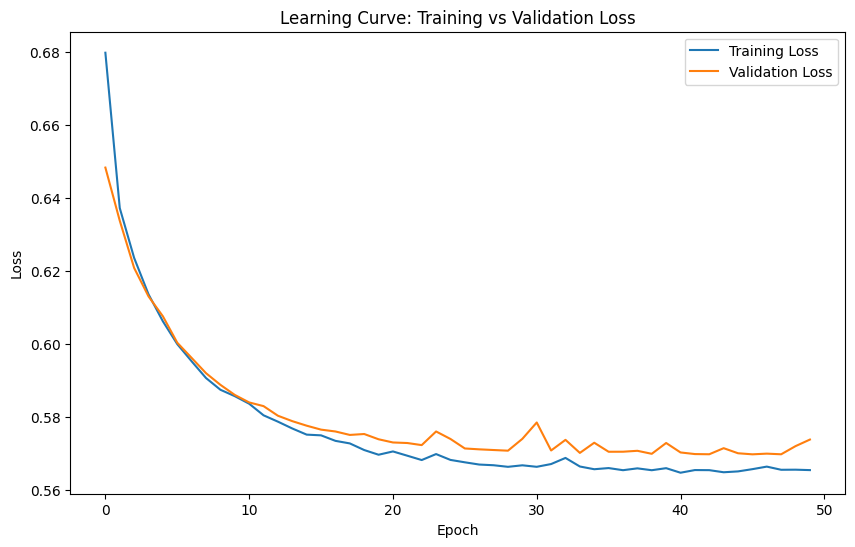

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve: Training vs Validation Loss')
plt.legend()
plt.show()

 الـ Learning Curve بتوضح إن الموديل استقر (plateaued) من epoch ~20، 
 من غير علامات overfitting (الفجوة بين train/val صغيرة وثابتة).
 ده بيأكد إن الأداء محدود بمحدودية الـ features المتاحة (2 بس)، 
 مش بمشكلة في تصميم أو تدريب الشبكة نفسها.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# التوقع على الـ test (الشبكة بترجع احتمالات، مش 0/1 مباشرة)
y_pred_proba = model.predict(X_test)

# تحويل الاحتمالات لتصنيف نهائي (threshold = 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

# التقييم
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Accuracy: 0.671280276816609
Precision: 0.6360225140712945
Recall: 0.7883720930232558
F1-score: 0.7040498442367601

Confusion Matrix:
[[243 194]
 [ 91 339]]
